In [3]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load dataset
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')

In [4]:
# Step 3: Data Cleaning
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (Invoice starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [5]:
# Step 4: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 5: Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [6]:
# Step 6: Calculate RFM Metrics

# Reference date (latest date in dataset + 1 day)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [7]:
# Step 7: Create RFM Scores using Quantiles

# Recency: lower is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

# Frequency & Monetary: higher is better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Convert to integer
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Combine RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [8]:
# Step 8: Assign Customer Segments

def segment_customer(row):
    if row['R_Score'] == 4 and row['F_Score'] == 4 and row['M_Score'] == 4:
        return 'Champions'
    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Potential Loyalists'
    elif row['R_Score'] == 2:
        return 'Needs Attention'
    elif row['R_Score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

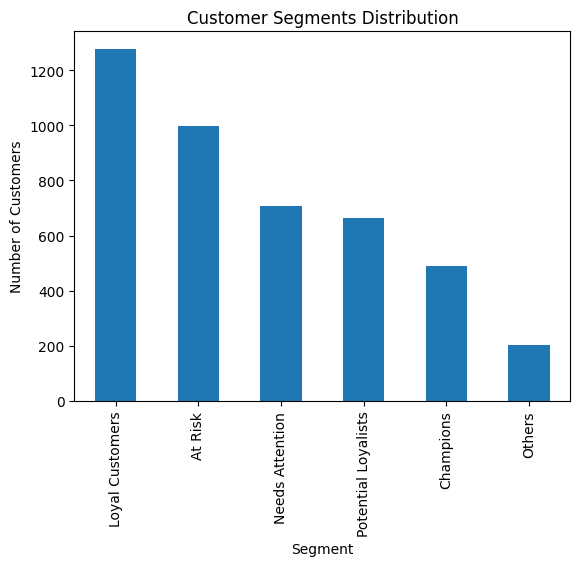

In [9]:
# Step 9: Visualize Segment Counts

segment_counts = rfm['Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
# Step 10: Export to CSV
rfm.to_csv("/content/RFM_Customer_Segmentation.csv")

print("RFM segmentation file saved successfully.")

RFM segmentation file saved successfully.
